# FS→DSA Italy — Exact Baseline Workflow

Purpose: Guarantee that all scenarios start from the same NFPC baseline and that a scenario with zero SPB change reproduces the NFPC DSA exactly, while any SPB change triggers endogenous responses.

Outline:
- Step 1: Exact NFPC replication from Table 17 (levels and growth) — produces `baseline_model`.
- Step 1b: Freeze NFPC baseline counterpart arrays into a reusable `scenario_template` for all subsequent runs.
- Step 2a: Apply MTP SPB path with NFPC anchors (only SPB differs) — endogenous DSA.
- Step 2b: Find binding SPB path (optimal) using the same NFPC anchors.
- Step 2c: Compare results in one chart.
- Step 3: Potential uplift with identical inflation to NFPC and recompute binding SPB.



In [22]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Resolve project root
cwd = Path.cwd()
project_root = cwd if (cwd / '03_Modell').exists() else cwd.parent
sys.path.extend([
    str((project_root / '03_Modell').parent),
    str(project_root / '03_Modell' / 'EU_DSA' / 'code' / 'classes')
])

from EU_DSA.code.classes import StochasticDsaModel as DSA
from FS_Model.integration import apply_mtp_anchors_to_dsa
from EU_DSA.code.functions import scenario_workflow  # New workflow functions
from FS_Model.data_functions import load_and_process_data
from FS_Model.model_equations import build_model
from FS_Model.scenario_functions import initialize_model, run_scenario_analysis
from FS_Model.integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb


START_YEAR, END_YEAR = 2024, 2041
ADJUSTMENT_START_YEAR = 2025
ADJUSTMENT_PERIOD = 7

print('Project root:', project_root)


Project root: c:\Users\dzsve\OneDrive - Dezernat Zukunft e.V\DZ-Schalte - Dokumente\2_Projekte\Fiskalpolitik\F48_EUCAM_DSA_Reformvorschlag


In [23]:
# load data and initialise FS model
IT = load_and_process_data(data_folder='02_Daten', sheet_name='Italy')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_IT = FS_model.insertModelVar(IT)
print('IT data shape:', IT.shape)

IT data shape: (84, 223)


In [24]:
# Initialize template DSA model
dsa_template = DSA(
    country='ITA',
    start_year=START_YEAR,
    end_year=END_YEAR,
    adjustment_period=ADJUSTMENT_PERIOD,
    adjustment_start_year=ADJUSTMENT_START_YEAR,
    fiscal_multiplier_type='ec'
)
dsa_template.project()
df_template = dsa_template.df(all=True)

a0 = dsa_template.adjustment_start
#a1 = dsa_template.adjustment_end
#closure_end = a1 + dsa_template.fiscal_multiplier_persistence
years = list(range(START_YEAR, END_YEAR + 1))

In [25]:
#Commission Excel
rg_pot_nfpc = pd.Series({
    2024: 1.04, 2025: 1.11, 2026: 0.96, 2027: 0.82, 2028: 0.72, 2029: 0.54, 2030: 0.41, 2031: 0.30,
    2032: 0.20, 2033: 0.16, 2034: 0.4, 2035: 0.64, 2036: 0.88, 2037: 1.01, 2038: 1.11, 2039: 1.22, 2040: 1.35, 2041: 1.36
}).reindex(years)

rg_nfpc = pd.Series({
    2024: 0.94, 2025: 1.04, 2026: 0.65, 2027: 0.40, 2028: 0.51, 2029: 0.54, 2030: 0.41, 2031: 0.30,
    2032: 0.20, 2033: 0.16, 2034: 0.4, 2035: 0.64, 2036: 0.88, 2037: 1.01, 2038: 1.11, 2039: 1.22, 2040: 1.35, 2041: 1.36
}).reindex(years)

pi_nfpc = pd.Series({
    2024: 2.2, 2025: 1.8, 2026: 1.9, 2027: 2.0, 2028: 2.1, 2029: 2.2, 2030: 2.3, 2031: 2.4,
    2032: 2.5, 2033: 2.6, 2034: 2.5, 2035: 2.5, 2036: 2.5, 2037: 2.4, 2038: 2.4, 2039: 2.3, 2040: 2.3, 2041: 2.2
}).reindex(years)

spb_target = pd.Series({
    2024: -0.5,     2025: 0,     2026: 0.6,     2027: 1.1,     2028: 1.6,     2029: 2.2,     2030: 2.7,     2031: 3.2, 
    2032: 3.0,     2033: 2.9,     2034: 2.8,     2035: 2.8,     2036: 2.7,     2037: 2.7,     2038: 2.7,     2039: 2.7,     2040: 2.7,     2041: 2.7, 
}).reindex(years)

## Step 1 — NFPC replication (Table 17)


In [26]:
NFPC = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,
    rg_pot=rg_pot_nfpc,
    pi=pi_nfpc,
    dsa_model=dsa_template,
    spb_baseline=-0.5,
    inplace=False
)
df_NFPC = NFPC.df(all=True)


## Step 2a — Apply MTP SPB (NFPC anchors; start from `scenario_template`)


In [27]:
spb_steps_mtp = np.zeros(ADJUSTMENT_PERIOD)
for tt in range(NFPC.adjustment_start, NFPC.adjustment_end + 1):
    yy = NFPC.start_year + tt
    spb_steps_mtp[tt - NFPC.adjustment_start] = spb_target.loc[yy] - spb_target.loc[yy - 1]

scenario_mtp, spb_steps_used, binding_spb = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    spb_steps_mtp=spb_steps_mtp,
    inplace=False
)

df_sce_mtp = scenario_mtp.df(all=True)


## Step 2b — Binding SPB path from NFPC anchors


In [28]:
print("Finding binding SPB path...")
binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_mtp = binding_mtp.df(all=True)
binding_spb_target = binding_mtp.binding_spb_target if binding_spb_target is None else binding_spb_target
print(f"Binding SPB target (2031): {binding_spb_target:.3f}%")
print(f"Binding SPB steps: {spb_steps_binding}")


Finding binding SPB path...
Binding SPB target (2031): 2.683%
Binding SPB steps: [0.5        0.5        0.5        0.6562089  0.34242601 0.34242601
 0.34242601]


## Step 2c — Comparison chart


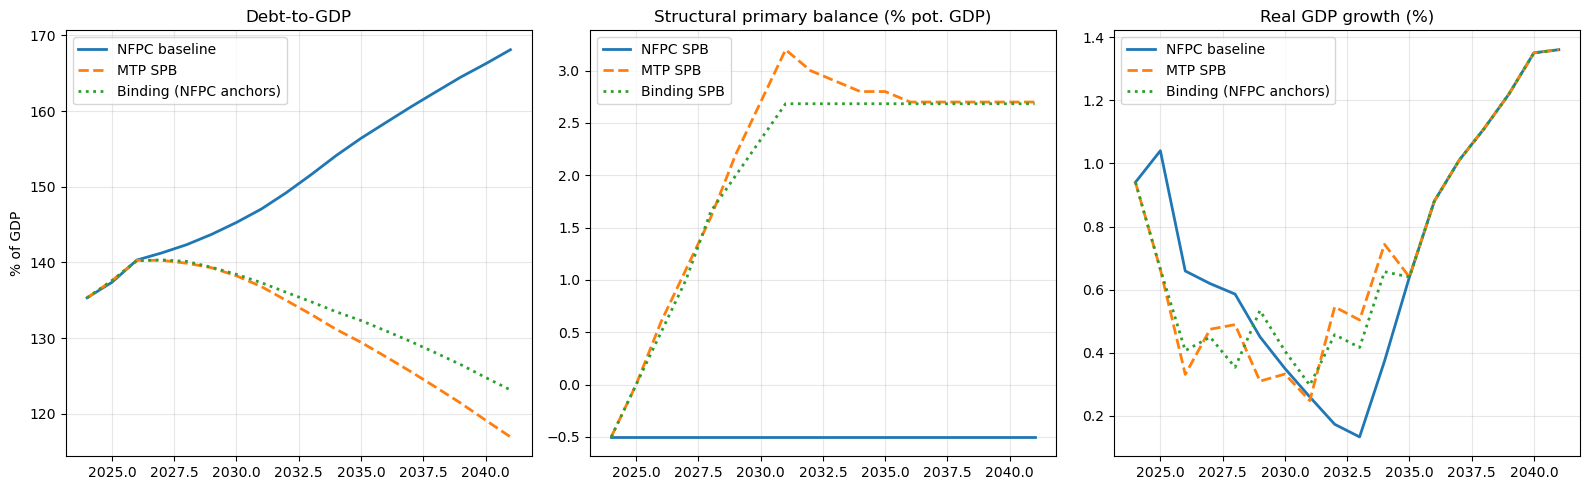

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Debt paths
ax = axes[0]
ax.plot(years, NFPC.d[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.d[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.d[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Debt-to-GDP'); ax.set_ylabel('% of GDP'); ax.grid(True, alpha=0.3); ax.legend()

# SPB
ax = axes[1]
ax.plot(years, np.full(len(years), -0.5), label='NFPC SPB', lw=2)
ax.plot(years, spb_target.values, '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.spb_bca[:len(years)], ':', label='Binding SPB', lw=2)
ax.set_title('Structural primary balance (% pot. GDP)'); ax.grid(True, alpha=0.3); ax.legend()

# Real growth
ax = axes[2]
ax.plot(years, NFPC.rg[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.rg[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.rg[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Real GDP growth (%)'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## Step 3 — Potential uplift (optional) with same inflation (NFPC)


In [30]:
measures = [
    # Measure 1: Active Labour market policies → EPS_LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.28196, 0.29106, 0.28196, 0.28196], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
]

In [31]:
# Extract paths from the binding DSA model
rg = pd.Series(NFPC.rg, index=years, name='rg')
rg_pot = pd.Series(NFPC.rg_pot, index=years, name='rg_pot')
pi = pd.Series(NFPC.pi, index=years, name='pi')
   
# Create the anchors dictionary
bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

FS_bl_IT = initialize_model(
    data=data_IT, 
    model_class=FS_model, 
    start=ADJUSTMENT_START_YEAR, 
    end=END_YEAR,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(NFPC),  # Use the NFPC model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

In [32]:
FS_sce_IT = run_scenario_analysis(
    baseline_result=FS_bl_IT, model_class=FS_model,
    scenario_shocks=measures, scenario_name='IT_PREM',
)

,Period 1,Period 2,Period 3,Period 4,Period 5
EPS_LP,0.000,0.282,0.291,0.282,0.282


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [33]:
# Calculate total growth from 2024 to 2041 for Italy (IT) — both Baseline and Scenario

# --- Scenario (with uplift) ---
start_value_sce = FS_bl_IT.loc[2024, 'Y_STAR']  # Use baseline 2024 value as starting point for both
end_value_sce = FS_sce_IT.loc[2041, 'Y_STAR']
total_growth_factor_sce = end_value_sce / start_value_sce

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate_sce = (total_growth_factor_sce ** (1/years_span)) - 1

# Create smoothed Y_STAR series with scenario constant growth
FS_sce_IT['Y_STAR_smooth'] = FS_sce_IT['Y_STAR'].copy()
FS_sce_IT.loc[2024, 'Y_STAR_smooth'] = start_value_sce

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    FS_sce_IT.loc[year, 'Y_STAR_smooth'] = start_value_sce * ((1 + constant_growth_rate_sce) ** (year - 2024))

# Calculate the smoothed growth rates
FS_sce_IT['Y_STAR_growth_smooth'] = FS_sce_IT['Y_STAR_smooth'].pct_change() * 100

# --- Baseline ---
start_value_bl = FS_bl_IT.loc[2024, 'Y_STAR']
end_value_bl = FS_bl_IT.loc[2041, 'Y_STAR']
total_growth_factor_bl = end_value_bl / start_value_bl

constant_growth_rate_bl = (total_growth_factor_bl ** (1/years_span)) - 1

# Optional: Create a similar baseline smoothed Y_STAR column if needed
FS_bl_IT['Y_STAR_smooth'] = FS_bl_IT['Y_STAR'].copy()
FS_bl_IT.loc[2024, 'Y_STAR_smooth'] = start_value_bl
for year in range(2025, 2042):
    FS_bl_IT.loc[year, 'Y_STAR_smooth'] = start_value_bl * ((1 + constant_growth_rate_bl) ** (year - 2024))
FS_bl_IT['Y_STAR_growth_smooth'] = FS_bl_IT['Y_STAR_smooth'].pct_change() * 100

print("---- Scenario (with uplift) ----")
print(f"Total growth factor (sce): {total_growth_factor_sce:.4f}")
print(f"Constant annual growth rate (sce): {constant_growth_rate_sce*100:.2f}%")
print(f"Growth from 2024 to 2041 (sce): {(total_growth_factor_sce-1)*100:.2f}%")
print("---- Baseline ----")
print(f"Total growth factor (bl): {total_growth_factor_bl:.4f}")
print(f"Constant annual growth rate (bl): {constant_growth_rate_bl*100:.2f}%")
print(f"Growth from 2024 to 2041 (bl): {(total_growth_factor_bl-1)*100:.2f}%")

---- Scenario (with uplift) ----
Total growth factor (sce): 1.1557
Constant annual growth rate (sce): 0.85%
Growth from 2024 to 2041 (sce): 15.57%
---- Baseline ----
Total growth factor (bl): 1.1403
Constant annual growth rate (bl): 0.78%
Growth from 2024 to 2041 (bl): 14.03%


In [34]:
rg_pot_policy = FS_sce_IT['Y_STAR'].pct_change() * 100
rg_pot_policy = rg_pot_policy.reindex(years).fillna(method='ffill').fillna(method='bfill')

print("\nCreating policy-responsive scenario with higher potential growth...")
print(f"Policy potential growth (2025-2030): {rg_pot_policy.loc[2025:2030].values}")

binding_PREM, spb_steps_policy, binding_spb_target_policy = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC,
    rg_pot_policy=rg_pot_policy,
    pi=None,
    use_find_binding=True,
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_PREM = binding_PREM.df(all=True)
sce_opt_tgt = float(binding_PREM.binding_spb_target) if binding_spb_target_policy is None else float(binding_spb_target_policy)
sce_opt_steps = spb_steps_policy.copy()

binding_spb_target_baseline = binding_mtp.binding_spb_target
binding_spb_target_policy_final = binding_PREM.binding_spb_target

print(f"\nBaseline Binding: {binding_spb_target_baseline:.3f}% vs Policy Binding: {binding_spb_target_policy_final:.3f}%")
print(f"Difference: {binding_spb_target_policy_final - binding_spb_target_baseline:.3f} percentage points")



Creating policy-responsive scenario with higher potential growth...
Policy potential growth (2025-2030): [1.11       1.2553746  1.12864177 1.0236055  0.84753331 0.4367895 ]

Baseline Binding: 2.683% vs Policy Binding: 2.621%
Difference: -0.063 percentage points


## 4) Results

In [35]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Italy

years_it = range(2024, 2042)  # 2024-2041 for Italy

# Helper function to get EUR values (Italy)
def get_eur_values_it(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Italy)
def get_pct_values_it(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Italy, including debt ratio and potential output growth
results_it = {
    'Year': list(years_it),
    'SPB_Baseline_%': [get_pct_values_it(binding_mtp, y, 'spb_bca') for y in years_it],
    'SPB_Scenario_%': [get_pct_values_it(binding_PREM, y, 'spb_bca') for y in years_it],
    'SPB_Baseline_EUR': [get_eur_values_it(binding_mtp, y, 'spb_bca') for y in years_it],
    'SPB_Scenario_EUR': [get_eur_values_it(binding_PREM, y, 'spb_bca') for y in years_it],
    'Debt_Baseline_%': [get_pct_values_it(binding_mtp, y, 'd') for y in years_it],
    'Debt_Scenario_%': [get_pct_values_it(binding_PREM, y, 'd') for y in years_it],
    'PotOut_Growth_Baseline_%': [get_pct_values_it(binding_mtp, y, 'rg_pot') for y in years_it],
    'PotOut_Growth_Scenario_%': [get_pct_values_it(binding_PREM, y, 'rg_pot') for y in years_it],
}

# Create DataFrame for Italy
comparison_df_it = pd.DataFrame(results_it)

# Calculate differences for Italy
comparison_df_it['SPB_Diff_%'] = comparison_df_it['SPB_Scenario_%'] - comparison_df_it['SPB_Baseline_%']
comparison_df_it['SPB_Diff_EUR'] = comparison_df_it['SPB_Scenario_EUR'] - comparison_df_it['SPB_Baseline_EUR']
comparison_df_it['Debt_Diff_%'] = comparison_df_it['Debt_Scenario_%'] - comparison_df_it['Debt_Baseline_%']
comparison_df_it['PotOut_Growth_Diff_%'] = comparison_df_it['PotOut_Growth_Scenario_%'] - comparison_df_it['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Italy):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_it = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_it = comparison_df_it.copy()
for col in eur_cols_it:
    comparison_df_display_it[col] = comparison_df_display_it[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_it.round(3))

SPB, Debt Ratio, and Potential Output Growth Comparison (Italy):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.500,-0.500,"-10,960,910,000","-10,960,910,000",135.326,135.326,1.040,1.267,0.000,0,0.000,0.227
1,2025,0.000,0.000,0,0,137.598,137.598,1.110,1.110,0.000,0,0.000,0.000
2,2026,0.500,0.500,"11,492,335,684","11,525,958,347",140.235,139.825,0.960,1.255,0.000,"33,622,663",-0.411,0.295
3,2027,1.000,1.000,"23,549,801,388","23,691,004,372",140.342,139.500,0.820,1.129,0.000,"141,202,984",-0.843,0.309
4,2028,1.656,1.642,"39,963,444,017","39,975,560,054",140.140,138.862,0.720,1.024,-0.015,"12,116,038",-1.278,0.304
5,2029,1.999,1.968,"49,550,151,192","49,394,178,469",139.360,137.657,0.540,0.848,-0.031,"-155,972,723",-1.703,0.308
6,2030,2.341,2.295,"59,615,536,911","59,168,826,069",138.430,136.703,0.410,0.437,-0.047,"-446,710,842",-1.727,0.027
7,2031,2.683,2.621,"70,183,583,201","69,433,524,583",137.323,135.589,0.300,0.325,-0.063,"-750,058,617",-1.734,0.025
8,2032,2.683,2.621,"72,267,315,754","71,504,018,723",136.050,134.340,0.200,0.222,-0.063,"-763,297,031",-1.711,0.022
9,2033,2.683,2.621,"74,455,287,684","73,675,901,934",134.806,133.128,0.160,0.179,-0.063,"-779,385,750",-1.679,0.019


In [36]:
# Save the comparison dataframe for Italy
comparison_df_it.to_excel('Italy_Results_v3.xlsx', index=False)
print("DataFrame saved as 'Italy_Results_v3.xlsx'")

DataFrame saved as 'Italy_Results_v3.xlsx'


## Step 4 — Smoothed Growth Rates Comparison


In [37]:
# Calculate smoothed potential output growth rate from NFPC baseline
# Target: constant growth rate that reaches the same potential output level in 2041

# Get NFPC potential output levels
start_year_nfpc = NFPC.start_year  # 2024
end_year_nfpc = NFPC.end_year  # 2041

start_rgdp_pot_nfpc = NFPC.rgdp_pot_bl[0]  # t=0 (2024)
end_rgdp_pot_nfpc = NFPC.rgdp_pot_bl[end_year_nfpc - start_year_nfpc]  # t=17 (2041)

# Calculate total growth factor
total_growth_factor = end_rgdp_pot_nfpc / start_rgdp_pot_nfpc

# Calculate constant annual growth rate (2024 to 2041 = 17 years)
years_span = end_year_nfpc - start_year_nfpc  # 17 years
constant_growth_rate_smoothed = (total_growth_factor ** (1/years_span)) - 1
constant_growth_rate_smoothed_pct = constant_growth_rate_smoothed * 100

print(f"NFPC Potential Output:")
print(f"  Start (2024): {start_rgdp_pot_nfpc:,.0f}")
print(f"  End (2041): {end_rgdp_pot_nfpc:,.0f}")
print(f"  Total growth factor: {total_growth_factor:.4f}")
print(f"  Constant annual growth rate (smoothed): {constant_growth_rate_smoothed_pct:.2f}%")
print(f"  Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

# Create smoothed growth rate series (should be ~0.78% for all years)
rg_pot_smoothed_baseline = pd.Series(
    [constant_growth_rate_smoothed_pct] * len(years),
    index=years,
    name='rg_pot_smoothed'
)

print(f"\nSmoothed baseline growth rate series:")
print(rg_pot_smoothed_baseline.head(5))
print("...")
print(rg_pot_smoothed_baseline.tail(5))


NFPC Potential Output:
  Start (2024): 1,916
  End (2041): 2,185
  Total growth factor: 1.1403
  Constant annual growth rate (smoothed): 0.78%
  Growth from 2024 to 2041: 14.03%

Smoothed baseline growth rate series:
2024   0.775
2025   0.775
2026   0.775
2027   0.775
2028   0.775
Name: rg_pot_smoothed, dtype: float64
...
2037   0.775
2038   0.775
2039   0.775
2040   0.775
2041   0.775
Name: rg_pot_smoothed, dtype: float64


In [42]:
## Step 4a — NFPC Baseline with smoothed growth rate (0.78%), then find binding SPB

print("Step 4a-1: Creating NFPC baseline with smoothed potential growth...")
print(f"Using constant growth rate: {constant_growth_rate_smoothed_pct:.2f}% per year")

# Step 1: Create NFPC baseline with smoothed growth rate
# Use smoothed growth rate only for potential growth, keep original real growth rates
NFPC_smoothed = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,  # Use original NFPC real growth rates
    rg_pot=rg_pot_smoothed_baseline,  # Use smoothed rate only for potential growth
    pi=pi_nfpc,  # Keep NFPC inflation
    dsa_model=dsa_template,
    spb_baseline=-0.5,
    inplace=False
)

df_NFPC_smoothed = NFPC_smoothed.df(all=True)

print(f"\nStep 4a-2: Finding binding SPB from smoothed NFPC baseline...")

# Step 2: Find binding SPB from smoothed NFPC baseline
binding_smoothed_baseline, spb_steps_smoothed_baseline, binding_spb_target_smoothed_baseline = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC_smoothed,
    use_find_binding=True,
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_smoothed_baseline = binding_smoothed_baseline.df(all=True)

binding_spb_target_smoothed_baseline_value = binding_smoothed_baseline.binding_spb_target if binding_spb_target_smoothed_baseline is None else binding_spb_target_smoothed_baseline

print(f"\n=== Smoothed NFPC Baseline Results ===")
print(f"NFPC with smoothed growth ({constant_growth_rate_smoothed_pct:.2f}%) created")
print(f"Binding SPB target (2031): {binding_spb_target_smoothed_baseline_value:.3f}%")
print(f"Binding SPB steps: {spb_steps_smoothed_baseline}")


Step 4a-1: Creating NFPC baseline with smoothed potential growth...
Using constant growth rate: 0.78% per year

Step 4a-2: Finding binding SPB from smoothed NFPC baseline...

=== Smoothed NFPC Baseline Results ===
NFPC with smoothed growth (0.78%) created
Binding SPB target (2031): 2.948%
Binding SPB steps: [0.5        0.5        0.5        0.65268286 0.4317463  0.4317463
 0.4317463 ]


In [48]:
## Step 4b — Policy-responsive scenario with higher smoothed growth rate (0.85%) from smoothed NFPC

# Create higher smoothed growth rate series (0.85% for all years)
rg_pot_smoothed_policy = pd.Series(
    [constant_growth_rate_sce*100] * len(years),
    index=years,
    name='rg_pot_smoothed_policy'
)

print("Creating policy-responsive scenario with higher smoothed potential growth (0.85%)...")
print(f"Starting from smoothed NFPC baseline ({constant_growth_rate_smoothed_pct:.2f}%)")
print(f"Applying higher constant growth rate: 0.85% per year")

# Create policy scenario with higher smoothed growth rate, starting from smoothed NFPC baseline
binding_smoothed_policy, spb_steps_smoothed_policy, binding_spb_target_smoothed_policy = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC_smoothed,  # Use smoothed NFPC as baseline
    rg_pot_policy=rg_pot_smoothed_policy,
    pi=None,  # Keep NFPC inflation
    use_find_binding=True,
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_smoothed_policy = binding_smoothed_policy.df(all=True)

binding_spb_target_smoothed_policy_value = binding_smoothed_policy.binding_spb_target if binding_spb_target_smoothed_policy is None else binding_spb_target_smoothed_policy

print(f"\n=== Smoothed Policy Results ===")
print(f"Binding SPB target (2031): {binding_spb_target_smoothed_policy_value:.3f}%")
print(f"Binding SPB steps: {spb_steps_smoothed_policy}")


Creating policy-responsive scenario with higher smoothed potential growth (0.85%)...
Starting from smoothed NFPC baseline (0.78%)
Applying higher constant growth rate: 0.85% per year

=== Smoothed Policy Results ===
Binding SPB target (2031): 2.837%
Binding SPB steps: [0.5        0.5        0.5        0.64932598 0.39576097 0.39576097
 0.39576097]


In [44]:
## Step 4c — Compare SPB Targets

print("=" * 70)
print("SPB TARGETS COMPARISON - SMOOTHED GROWTH RATES")
print("=" * 70)

print(f"\nSmoothed Baseline ({constant_growth_rate_smoothed_pct:.2f}%):  {binding_spb_target_smoothed_baseline_value:.3f}%")
print(f"Smoothed Policy (0.85%):                     {binding_spb_target_smoothed_policy_value:.3f}%")
print(f"Difference:                                   {binding_spb_target_smoothed_policy_value - binding_spb_target_smoothed_baseline_value:+.3f} percentage points")

print(f"\nComparison with original scenarios:")
print(f"Original Baseline Binding:                    {binding_mtp.binding_spb_target:.3f}%")
print(f"Original Policy Binding:                     {binding_PREM.binding_spb_target:.3f}%")
print(f"Smoothed Baseline ({constant_growth_rate_smoothed_pct:.2f}%):                    {binding_spb_target_smoothed_baseline_value:.3f}%")
print(f"Smoothed Policy (0.85%):                     {binding_spb_target_smoothed_policy_value:.3f}%")

# Create comparison DataFrame
comparison_smoothed = pd.DataFrame({
    'Scenario': [
        'Original Baseline',
        'Original Policy',
        f'Smoothed Baseline ({constant_growth_rate_smoothed_pct:.2f}%)',
        'Smoothed Policy (0.85%)'
    ],
    'SPB_Target_2031_%': [
        binding_mtp.binding_spb_target,
        binding_PREM.binding_spb_target,
        binding_spb_target_smoothed_baseline_value,
        binding_spb_target_smoothed_policy_value
    ],
    'Growth_Rate_Type': [
        'NFPC variable',
        'FS scenario variable',
        f'Smoothed constant {constant_growth_rate_smoothed_pct:.2f}%',
        'Smoothed constant 0.85%'
    ]
})

print("\nSummary Table:")
display(comparison_smoothed.round(3))


SPB TARGETS COMPARISON - SMOOTHED GROWTH RATES

Smoothed Baseline (0.78%):  2.948%
Smoothed Policy (0.85%):                     2.843%
Difference:                                   -0.105 percentage points

Comparison with original scenarios:
Original Baseline Binding:                    2.683%
Original Policy Binding:                     2.621%
Smoothed Baseline (0.78%):                    2.948%
Smoothed Policy (0.85%):                     2.843%

Summary Table:


,Scenario,SPB_Target_2031_%,Growth_Rate_Type
0,Original Baseline,2.683,NFPC variable
1,Original Policy,2.621,FS scenario variable
2,Smoothed Baseline (0.78%),2.948,Smoothed constant 0.78%
3,Smoothed Policy (0.85%),2.843,Smoothed constant 0.85%


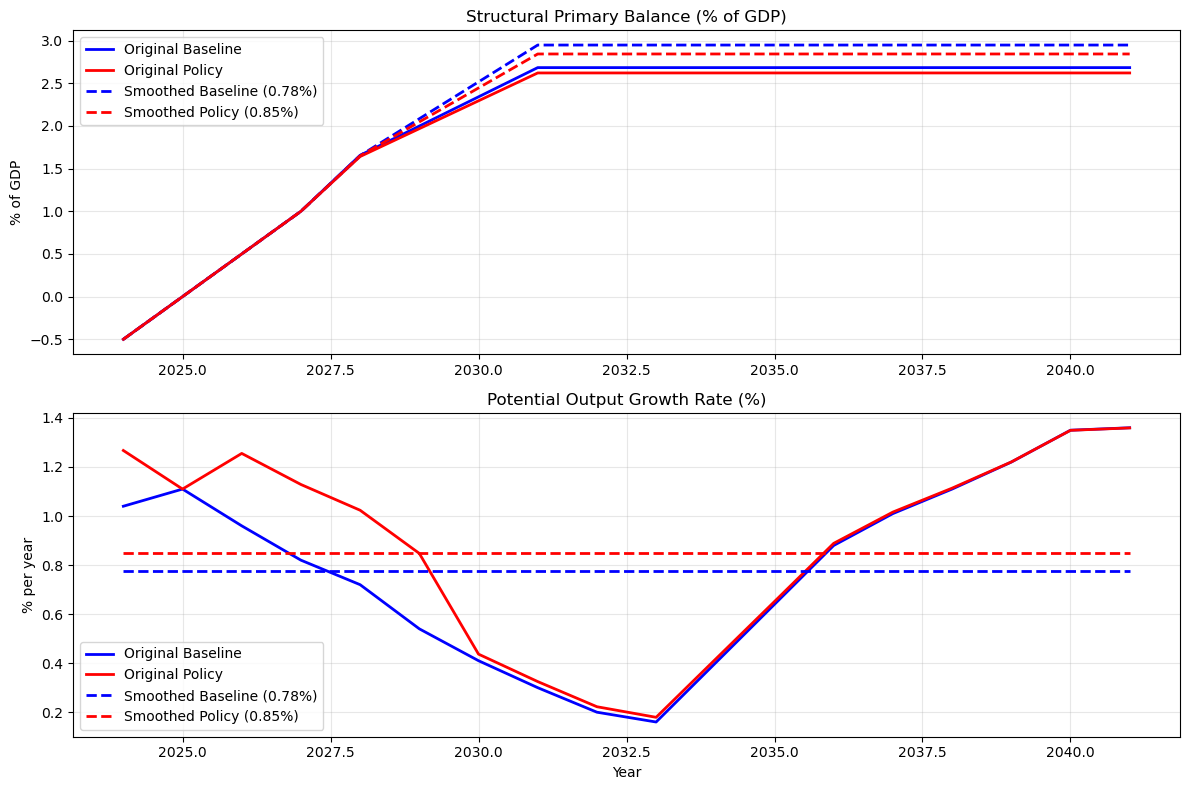

In [45]:
## Step 4d — Visualization of Smoothed Scenarios

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

years_plot = range(2024, 2042)

# Plot 1: SPB paths
ax1 = axes[0]
ax1.plot(years_plot, binding_mtp.spb_bca[:len(years_plot)], 'b-', label='Original Baseline', lw=2)
ax1.plot(years_plot, binding_PREM.spb_bca[:len(years_plot)], 'r-', label='Original Policy', lw=2)
ax1.plot(years_plot, binding_smoothed_baseline.spb_bca[:len(years_plot)], 'b--', label=f'Smoothed Baseline ({constant_growth_rate_smoothed_pct:.2f}%)', lw=2)
ax1.plot(years_plot, binding_smoothed_policy.spb_bca[:len(years_plot)], 'r--', label='Smoothed Policy (0.85%)', lw=2)
ax1.set_title('Structural Primary Balance (% of GDP)')
ax1.set_ylabel('% of GDP')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Potential Output Growth Rates
ax2 = axes[1]
ax2.plot(years_plot, binding_mtp.rg_pot[:len(years_plot)], 'b-', label='Original Baseline', lw=2)
ax2.plot(years_plot, binding_PREM.rg_pot[:len(years_plot)], 'r-', label='Original Policy', lw=2)
ax2.plot(years_plot, binding_smoothed_baseline.rg_pot[:len(years_plot)], 'b--', label=f'Smoothed Baseline ({constant_growth_rate_smoothed_pct:.2f}%)', lw=2)
ax2.plot(years_plot, binding_smoothed_policy.rg_pot[:len(years_plot)], 'r--', label='Smoothed Policy (0.85%)', lw=2)
ax2.set_title('Potential Output Growth Rate (%)')
ax2.set_ylabel('% per year')
ax2.set_xlabel('Year')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


In [50]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Smoothed Baseline vs Smoothed Scenario for Italy

years_it = range(2024, 2042)  # 2024-2041 for Italy

# Create data dictionary for smoothed scenarios, including debt ratio and potential output growth
results_it_smoothed = {
    'Year': list(years_it),
    'SPB_SmoothedBaseline_%': [get_pct_values_it(binding_smoothed_baseline, y, 'spb_bca') for y in years_it],
    'SPB_SmoothedScenario_%': [get_pct_values_it(binding_smoothed_policy, y, 'spb_bca') for y in years_it],
    'SPB_SmoothedBaseline_EUR': [get_eur_values_it(binding_smoothed_baseline, y, 'spb_bca') for y in years_it],
    'SPB_SmoothedScenario_EUR': [get_eur_values_it(binding_smoothed_policy, y, 'spb_bca') for y in years_it],
    'Debt_SmoothedBaseline_%': [get_pct_values_it(binding_smoothed_baseline, y, 'd') for y in years_it],
    'Debt_SmoothedScenario_%': [get_pct_values_it(binding_smoothed_policy, y, 'd') for y in years_it],
    'PotOut_Growth_SmoothedBaseline_%': [get_pct_values_it(binding_smoothed_baseline, y, 'rg_pot') for y in years_it],
    'PotOut_Growth_SmoothedScenario_%': [get_pct_values_it(binding_smoothed_policy, y, 'rg_pot') for y in years_it],
}

# Create DataFrame for smoothed scenarios
comparison_df_it_smoothed = pd.DataFrame(results_it_smoothed)

# Calculate differences for smoothed scenarios
comparison_df_it_smoothed['SPB_Diff_%'] = comparison_df_it_smoothed['SPB_SmoothedScenario_%'] - comparison_df_it_smoothed['SPB_SmoothedBaseline_%']
comparison_df_it_smoothed['SPB_Diff_EUR'] = comparison_df_it_smoothed['SPB_SmoothedScenario_EUR'] - comparison_df_it_smoothed['SPB_SmoothedBaseline_EUR']
comparison_df_it_smoothed['Debt_Diff_%'] = comparison_df_it_smoothed['Debt_SmoothedScenario_%'] - comparison_df_it_smoothed['Debt_SmoothedBaseline_%']
comparison_df_it_smoothed['PotOut_Growth_Diff_%'] = comparison_df_it_smoothed['PotOut_Growth_SmoothedScenario_%'] - comparison_df_it_smoothed['PotOut_Growth_SmoothedBaseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison - Smoothed Scenarios (Italy):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_it_smoothed = ['SPB_SmoothedBaseline_EUR', 'SPB_SmoothedScenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_it_smoothed = comparison_df_it_smoothed.copy()
for col in eur_cols_it_smoothed:
    comparison_df_display_it_smoothed[col] = comparison_df_display_it_smoothed[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_it_smoothed.round(2))


SPB, Debt Ratio, and Potential Output Growth Comparison - Smoothed Scenarios (Italy):


,Year,SPB_SmoothedBaseline_%,SPB_SmoothedScenario_%,SPB_SmoothedBaseline_EUR,SPB_SmoothedScenario_EUR,Debt_SmoothedBaseline_%,Debt_SmoothedScenario_%,PotOut_Growth_SmoothedBaseline_%,PotOut_Growth_SmoothedScenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.500,-0.500,"-10,960,910,000","-10,960,910,000",135.330,135.330,0.780,0.850,0.000,0,0.000,0.080
1,2025,0.000,0.000,0,0,137.410,137.460,0.780,0.850,0.000,0,0.040,0.080
2,2026,0.500,0.500,"11,458,866,457","11,470,869,508",140.340,140.270,0.780,0.850,0.000,"12,003,051",-0.070,0.080
3,2027,1.000,1.000,"23,453,450,279","23,500,682,030",140.530,140.340,0.780,0.850,0.000,"47,231,751",-0.190,0.080
4,2028,1.650,1.650,"39,718,371,452","39,754,565,321",140.270,139.960,0.780,0.850,-0.000,"36,193,868",-0.310,0.080
5,2029,2.080,2.050,"51,537,780,215","50,771,567,257",139.210,138.780,0.780,0.850,-0.040,"-766,212,959",-0.440,0.080
6,2030,2.520,2.440,"64,090,921,502","62,489,736,235",137.730,137.210,0.780,0.850,-0.080,"-1,601,185,268",-0.520,0.080
7,2031,2.950,2.840,"77,449,175,883","74,975,915,076",135.820,135.250,0.780,0.850,-0.110,"-2,473,260,807",-0.570,0.080
8,2032,2.950,2.840,"80,236,535,089","77,722,263,324",133.480,132.910,0.780,0.850,-0.110,"-2,514,271,765",-0.560,0.080
9,2033,2.950,2.840,"83,204,588,409","80,647,196,042",131.090,130.550,0.780,0.850,-0.110,"-2,557,392,366",-0.540,0.080


In [53]:
# Save the comparison dataframe for Italy
comparison_df_it_smoothed.to_excel('Italy_Results_v4.xlsx', index=False)
print("DataFrame saved as 'Italy_Results_v4.xlsx'")

DataFrame saved as 'Italy_Results_v4.xlsx'
